<style> 
      /* The . with the boxed represents that it is a class */
      .boxed {
        background: #e6fffe; /* C5F7F8 E5FAFA E1FCFC  #ecfffe #E5FAFA*/
        color: #0b3357; /* gray navy*/
        border: 3px solid #2980B9;
        margin: 10% auto;
        width: 95%;
        height: 95%;
        padding: 20px;
        border-radius: 20px;
      }
    </style>


If you’ve interacted with AI assistants of LLMs (Large Language Model) in the past you may have noticed a parameter called **Temperature**.
<br><br> 
Here we'll look at how temperature affects LLM outputs, its calculation, and some examples of varying temperature values. 



## What exactly is an LLM’s Temperature?

::: boxed
**LLM Temperature** is a parameter that controls the probability distribution of the predicted next words of an LLM. It introduces some randomness or variety to the LLM’s outputs by changing the liklihood of the next words being selected. It can influence the LLM’s outputs to be either more deterministic (predictable) or more stochastic (random). Parameters like temperature are used to simulate or mimic the inherent variation in human language generation.  

In production temperature values can typically range between 0-2+.   

* **Lower temperature** values (<1) can lead to more deterministic or predictable LLM outputs, referred to as making the LLM more “precise”.

* **Temperature of 1** defaults to the LLMs inherent word distribution learned during training. It's just the unaltered softmax function (more on this later).

* **Higher temperature** values (>1) can lead to more stochastic or random and varied LLM outputs, referred to as making the LLM more “creative”.
:::

When the temperature value is set to 0, most systems trigger greedy sampling for next word predictions, which simply takes the word with the highest probability in the vocabulary (*Note*: other sampling methods exist for text generation see [here](https://huggingface.co/docs/transformers/en/generation_strategies)). In some cases (if not properly controlled) the temperature value is **too high (>>2)** or **too low (=0)** this can trigger degenerate behavior like repetitive loops or LLM hallucinations. 

**Hallucinations** (metaphorically related to human hallucinations where a person may see or hear things that are not physically there) are LLM outputs that sometimes read as plausible but are factually wrong, or incoherent nonsensical text. It should be noted that temperature values between 0-2 do not prevent LLM hallucinations, they simply introduce randomness/diversity into the LLM outputs. Strategies like RAG (Retrieval Augmented Generation), CoT (Chain of Thought) etc. can be used to reduce hallucinations.  



<img src="LLM_temp_scale.gif" alt="Changing the temperature scale of the LLM adjusts the probability distribution of words predicted by the LLM" width="65%" height="auto" style="display: block; margin-left: auto; margin-right: auto; border: none;"/>




## The Math

### LLM Recap
Before diving deeper into the math let's side track to rember how LLM calculations work (*overly simplified*). 
<br>
<br>
LLMs can be thought of as next word prediction machines, where predications are made from what they've learned during training. 
<br>
Input text to the LLM are **tokenized** (words --> numbers), **encoded** to vector representaitons, passed to a **decoder** which produces **logits** that are then transformed to a probability distribution with a **softmax** function and the next word is selected from that distribution. 


[INSERT IMAGE OF LLM]


### The Softmax Function and Temperature

The **softmax function** is a widely used mathematical transformation that takes a set of values and transforms them into a set of probabilities that sum to 1. In NLP (Natural Language Processing) the softmax function takes the logits produced by LLMs and creates a scaled distribution of next words. 
<br>
The softmax function is defined as:

$$
\mathbf{Softmax}(x_i) = \frac{ \textcolor{None}{  e^{x_i} } }{ \textcolor{None}{ \sum_{j=1}^{N} e^{x_j}  } }
$$ 

Where:

* $x_i$ value of each input
* $e^{x_i}$ is the exponentiation of the value of each input (Euler's number: $e$ ~ $2.71828$) 
* $\sum_{j=1}^{N} e^{x_j}$ is the sum of all the exponentiated ($e$) inputs ($x$)

All this means is take each value of $x$, raise $e$ to that value and divide it by the sum of $e$ raised to each value of $x$.


##### Example 1 - Simple Softmax Transformation

<details>
<summary>Example</summary>

Given a list of numbers calculate their softmax probabilities.

* $list = [1, 2, 3]$

<br>
**Calculations**

$$
\begin{align*}
\mathbf{Softmax}(x_i) & = \frac{ \textcolor{steelblue}{  e^{x_i} } }{ \textcolor{purple}{ \sum_{j=1}^{N} e^{x_j}  } } \\
\end{align*}
$$

</details>

##### Example 2 - LLM Output Softmax Transformation

<details>
<summary>Example</summary>
Given a list of logit outputs from a LLM, find the most probable word and its probability. 
<br>
Assume the that LLM only knows 5 words (LLM vocabularies typically contain thousands of words). 

* $index = [0, 1, 2, 3, 4]$
* $words = [ceiling, floor, mat, car, grass]$
* $logits = [-49.82, -46.40, -45.25, -47.30, -48.32]$

<br>
**Calculations**
$$
\begin{align*}
\mathbf{Softmax}(x_i) & = \frac{ \textcolor{steelblue}{  e^{x_i} } }{ \textcolor{purple}{ \sum_{j=1}^{N} e^{x_j}  } } \\
\end{align*}
$$

Calculate the denominator using all the $logits$

$$
\begin{align*}
\textcolor{purple}{ D }  := \textcolor{purple}{ \sum_{j=1}^{N} e^{x_j}  }  & = \textcolor{purple}{ \sum_{j=1}^{N = 5} e^{x_j} }\\
& =  \textcolor{purple}{ e^{x_1} +  e^{x_2} +  e^{x_3} +  e^{x_4} +  e^{x_5} }\\
& =  \textcolor{purple}{ e^{-49.82} +  e^{-46.40} +  e^{-45.25} +  e^{-47.30} +  e^{-48.32} }\\
& =  \textcolor{purple}{ 2.309 * 10^{-22} +  7.059 * 10^{-21} + 2.229 * 10^{-20} +  2.870 * 10^{-21}  +  1.035 * 10^{-21} }\\
\textcolor{purple}{ D } & =  \textcolor{purple}{  3.349* 10^{-20}  }\\
\end{align*}
$$


Now do the full calculation for each of the $logits$  $x_{i=1:5}$

$$
\begin{align*}
\mathbf{Softmax}(x_{i=1:5}) & := \frac{ \textcolor{steelblue}{  e^{x_i} } }{ \textcolor{purple}{ \sum_{j=1}^{N} e^{x_j}  } } :=  \frac{ \textcolor{steelblue}{  e^{x_i} } }{ \textcolor{purple}{ D } } \\
      \\  
& =  \frac{ \textcolor{steelblue}{e^{x_1}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{x_2}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{x_3}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{x_4}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{x_5}} }{\textcolor{purple}{D}}\\
      \\  
& =  \frac{ \textcolor{steelblue}{e^{-49.82}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{-46.40}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{-45.25}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{-47.30}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{e^{-48.32}} }{\textcolor{purple}{D}} \\    
      \\  
& =  \frac{ \textcolor{steelblue}{ 2.309 * 10^{-22} } }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{ 7.059 * 10^{-21}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{ 2.229 * 10^{-20}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{ 2.870 * 10^{-21}} }{\textcolor{purple}{D}} ,
     \frac{ \textcolor{steelblue}{ 1.035 * 10^{-21}} }{\textcolor{purple}{D}} \\ 
     \\  
& =  \frac{ \textcolor{steelblue}{ 2.309 * 10^{-22} } }{\textcolor{purple}{ 3.349* 10^{-20} }}, 
     \frac{ \textcolor{steelblue}{ 7.059 * 10^{-21}} }{\textcolor{purple}{ 3.349* 10^{-20} }}, 
     \frac{ \textcolor{steelblue}{ 2.229 * 10^{-20}} }{\textcolor{purple}{ 3.349* 10^{-20} }}, 
     \frac{ \textcolor{steelblue}{ 2.870 * 10^{-21}} }{\textcolor{purple}{ 3.349* 10^{-20} }},
     \frac{ \textcolor{steelblue}{ 1.035 * 10^{-21}} }{\textcolor{purple}{ 3.349* 10^{-20} }} \\    
      \\               
& = 0.007, 0.211, 0.666, 0.086, 0.031 \\
     \\
Probabilities & = [0.007, 0.211, \textcolor{green}{0.666}, 0.086, 0.031] \\
     \\
argmax(Probabilities_{1:5}) & = 3 (Index:2)
\end{align*}
$$

<br>


The third element (index 2 in $Probabilities$) of the softmax probabilities is the largest ($\textcolor{green}{0.666}$), indicating that the word $\textcolor{green}{mat}$ (index 2 in $words$ array) is the most probable next word. 

In [367]:

# Example Softmax Calculation

# Assume for simplicity:
# * The model only knows the 5 words listed below (it has a vocabulary of 5).

import pandas as pd
import seaborn as sns

#Example model output
model_output_vals = {"word_index":[i for i in range(5)],
                "words":["ceiling", "floor", "mat", "car", "grass"], 
                "logits":[-49.82, -46.40, -45.25, -47.30, -48.32]}

#Convert the data to a DataFrame
model_output = pd.DataFrame(model_output_vals)

display(model_output)



#Define a softmax function
def my_softmax(input_vector):
    e = np.exp(input_vector)
    return e / e.sum()

#Calculate the probabilities
probs =  my_softmax(model_output["logits"])
model_output["softmax_prob"] = probs 



# print(f"Calculated probabilities: {probs}")

#Select the most probable word
most_prob = np.argmax(probs)
print(f"\nThe index of the most probable word is: {most_prob}")

#Pull out the most probable word
print(f"\nThe most probable word is: { model_output['words'][most_prob] }" \
      f" (Prob: {model_output['softmax_prob'][most_prob]:.5f})")


#Style our table

cm = sns.light_palette("orange", as_cmap=True)
s1 = model_output
s1 = s1.style.background_gradient(subset=["logits"],cmap=cm)

cm = sns.light_palette("green", as_cmap=True)
s1.background_gradient(subset=["softmax_prob"],cmap=cm)
# s1.bar(subset=["softmax_prob"], color='#00B8EA') # Blue colour



,word_index,words,logits
0,0,ceiling,-49.82
1,1,floor,-46.40
2,2,mat,-45.25
3,3,car,-47.30
4,4,grass,-48.32



The index of the most probable word is: 2

The most probable word is: mat (Prob: 0.66571)


,word_index,words,logits,softmax_prob
0,0,ceiling,-49.820000,0.006895
1,1,floor,-46.400000,0.210789
2,2,mat,-45.250000,0.665712
3,3,car,-47.300000,0.085700
4,4,grass,-48.320000,0.030903


In [365]:
np.exp(model_output_vals["logits"]) /np.exp(model_output_vals["logits"]).sum()

1.0

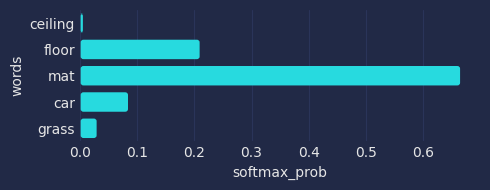

In [350]:
from matplotlib.patches import FancyBboxPatch

plt.subplots(figsize=(5, 2))
sns.set_color_codes("pastel")
ax = sns.barplot(y = model_output.words, 
                 x = model_output.softmax_prob, 
                                orient = "h", 
                                joinstyle='bevel')

new_patches = []
for patch in reversed(ax.patches):
    bb = patch.get_bbox()
    color = patch.get_facecolor()
    p_bbox = FancyBboxPatch((bb.xmin, bb.ymin),
                            abs(bb.width), abs(bb.height),
                            boxstyle="round,pad=-0.00150,rounding_size=0.005",
                            ec="none", fc=color,
                            mutation_aspect=20
                            )
    patch.remove()
    new_patches.append(p_bbox)

for patch in new_patches:
    ax.add_patch(patch)

sns.despine(left=True, bottom=True)
ax.tick_params(axis=u'both', which=u'both', length=0)
plt.tight_layout()
plt.show()


# #   joinstyle='bevel', 
# new_patches = []
# for patch in reversed(ax.patches):
#     # print(bb.xmin, bb.ymin,abs(bb.width), abs(bb.height))
#     bb = patch.get_bbox()
#     color = patch.get_facecolor()
#     p_bbox = FancyBboxPatch((bb.xmin, bb.ymin),
#                             abs(bb.width), abs(bb.height),
#                             boxstyle="round,pad=-0.05,rounding_size=2",
#                             ec="none", fc=color,
#                             mutation_aspect=0.1
#                             )
#     patch.remove()
#     new_patches.append(p_bbox)

# for patch in new_patches:
#     ax.add_patch(patch)

# sns.despine(left=True, bottom=True)

# ax.tick_params(axis=u'both', which=u'both', length=0)
# plt.tight_layout()
# # plt.savefig("data.png", bbox_inches="tight")
# plt.show()




# #Plot the outcomes
# fig, ax = plt.subplots()
# bars = ax.barh(model_output.words[::-1], 
#         model_output.softmax_prob[::-1])


# # bars = plt.barh(model_output.words[::-1], 
# #         model_output.softmax_prob[::-1])

# # Function to create rounded bars
# def round_bar(x, y, width, height, color):
#     bbox = FancyBboxPatch((x, y), width, height,
#                           boxstyle="round,pad=0.1",
#                           edgecolor='black',
#                           facecolor=color)
#     return bbox

# # Replace bars with rounded bars
# for bar in bars:
#     bbox = round_bar(bar.get_x(), bar.get_y(), bar.get_width(), bar.get_height(), bar.get_facecolor())
#     ax.add_patch(bbox)
#     bar.set_visible(False)



#### The Softmax Function



### Example - Temperature Calculation



## Examples or Varying Temperature
Let's dive in with some examples. <br>
To see how the temperature parameter affects the LLM outputs we'll use the [GPT-2 model by OpenAI](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) for text generation. The GPT-2 model is a fairly small, open sourced model that can be accessed and used via [Hugging Face](https://huggingface.co/docs/transformers/model_doc/gpt2).<br>
GPT-2 has:

 - 1.5 billion parameters

 - 50257 vocabulary size (number of words it knows)

 - 768 vector embedding size

 - 12 attention heads

 - 12 layers 

### Examples 1 - Next word generation
Suppose we’re given a sentence; how does temperature affect the next predicted word? 

Sentence: The cat slept on the ______.


### Example 2- Continuous word generation
How does temperature affect the output of continuous next word generation? 

Temp: 0.25

Sentence: The cat slept on the ______.

Sentence: The cat slept on the floor ______.

Sentence: The cat slept on the floor at ______.

Sentence: The cat slept on the floor at night ______.



Temp: 0.5
Sentence: The cat slept on the ______.
Sentence: The cat slept on the floor ______.
Sentence: The cat slept on the floor at ______.
Sentence: The cat slept on the floor at night ______.


Temp: 2.0
Sentence: The cat slept on the ______.
Sentence: The cat slept on the floor ______.
Sentence: The cat slept on the floor at ______.
Sentence: The cat slept on the floor at night ______.


Temp: 3.0
Sentence: The cat slept on the ______.
Sentence: The cat slept on the floor ______.
Sentence: The cat slept on the floor at ______.
Sentence: The cat slept on the floor at night ______.




## LLM Recap
LLMs work as next word prediction machines, given some input (over simplified). Those next word predictions come from a probability distribution of all the words that the model knows (its vocabulary). Layers within the transformer architecture (the structure that makes LLMs) produce logits, which are transformed to a probability distribution using a **softmax function**.




### The Softmax function
The softmax function is a widely used mathematical transformation that takes a set of values and transforms them into a set of probabilities that sum to 1. 

In [299]:
model_output.words[::-1]

4      grass
3        car
2        mat
1      floor
0    ceiling
Name: words, dtype: object

In [245]:
model_output["words"][2]

'mat'

In [237]:
vect = [1, 3, 2]
e = np.exp(vect)
print(e)
print(e.sum())

print(my_softmax(vect))

[ 2.71828183 20.08553692  7.3890561 ]
30.19287485057736
[0.09003057 0.66524096 0.24472847]


In [231]:
#| echo: false
import os
from tqdm import tqdm
import numpy as np

In [2]:
import torch
torch.cuda.device_count()
# print(torch.cuda.get_device_name())
# Check if a GPU is available
if torch.cuda.is_available():
    # Set the device to the first GPU (index 0)
    device = torch.device("cuda:1")
else:
    device = torch.device("cpu")

In [3]:
import torch
def list_cuda_devices():
    if torch.cuda.is_available():
        num_devices = torch.cuda.device_count()
        print("Number of CUDA devices:", num_devices)
        for i in range(num_devices):
            device_name = torch.cuda.get_device_name(i)
            print(f"Device {i}: {device_name}")
    else:
        print("No CUDA devices found.")

list_cuda_devices()

Number of CUDA devices: 3
Device 0: Quadro RTX 4000
Device 1: Quadro M4000
Device 2: Quadro P1000


In [4]:
try:
  from google.colab import userdata
  def get_api_key(key_name):
    return userdata.get(key_name)

except:
  from dotenv import load_dotenv, dotenv_values
  load_dotenv()
  def get_api_key(key_name):
    return os.environ.get(key_name)

In [5]:
#Download the model 
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

model_to_load = "openai-community/gpt2" #"microsoft/Phi-3-mini-4k-instruct"
model_to_load_task = "text-generation"

#Load the model's pretrained tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_to_load)

#Load the pretrained model
model = AutoModelForCausalLM.from_pretrained(
    model_to_load,
    device_map = "cuda:1",
    torch_dtype = "auto",
    trust_remote_code = True
)

# Enable gradient checkpointing
model.gradient_checkpointing_enable()

2024-10-28 21:18:06.097403: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-28 21:18:06.113531: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-28 21:18:06.133300: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-28 21:18:06.141213: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-28 21:18:06.156320: I tensorflow/core/platform/cpu_feature_guar

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Generated word:  floor         ( token index: 4314,          logit:-82.82,          prob: 1.0000 )


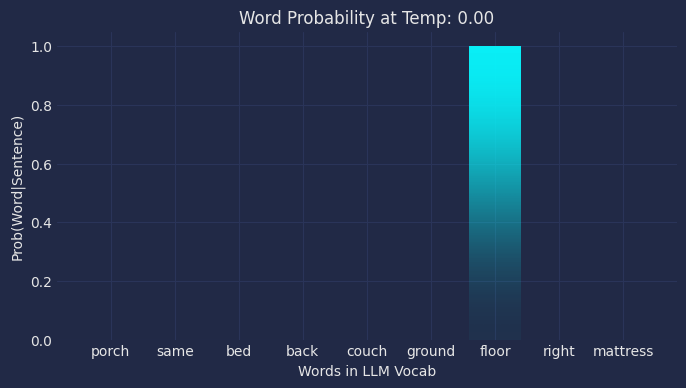

Generated word:  floor         ( token index: 4314,          logit:-82.82,          prob: 0.8213 )


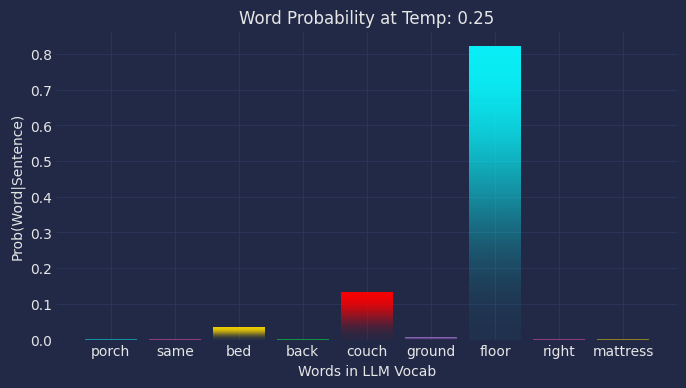

Generated word:  bed         ( token index: 3996,          logit:-83.61,          prob: 0.1118 )


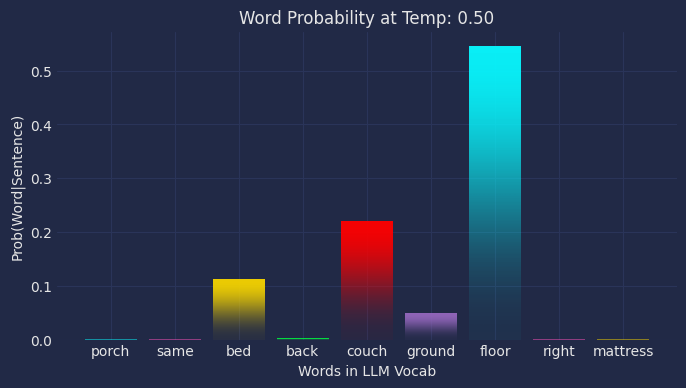

Generated word:  ground         ( token index: 2323,          logit:-84.01,          prob: 0.0574 )


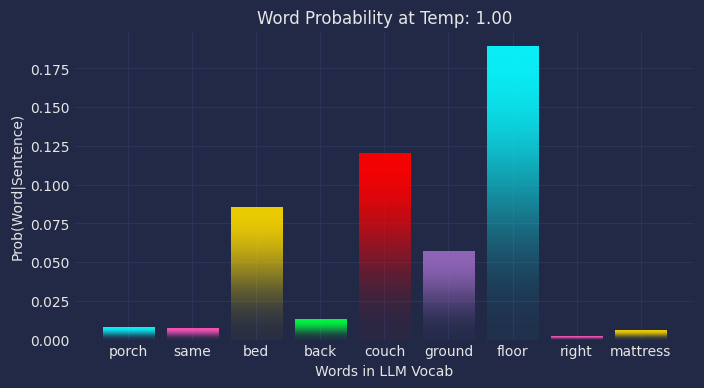

Generated word:  back         ( token index: 736,          logit:-85.49,          prob: 0.0027 )


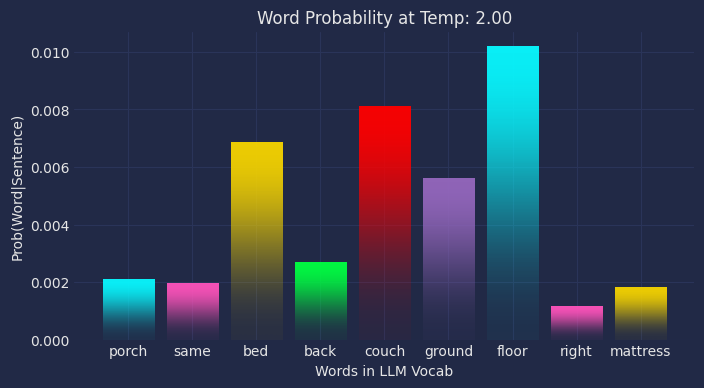

Generated word:  couch         ( token index: 18507,          logit:-83.27,          prob: 0.0003 )


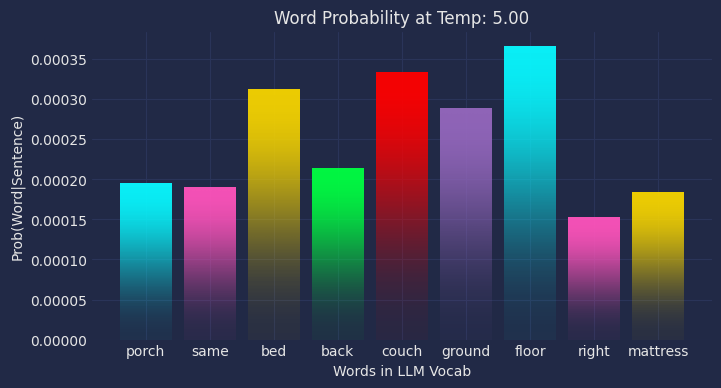

Generated word:  same         ( token index: 976,          logit:-86.10,          prob: 0.0001 )


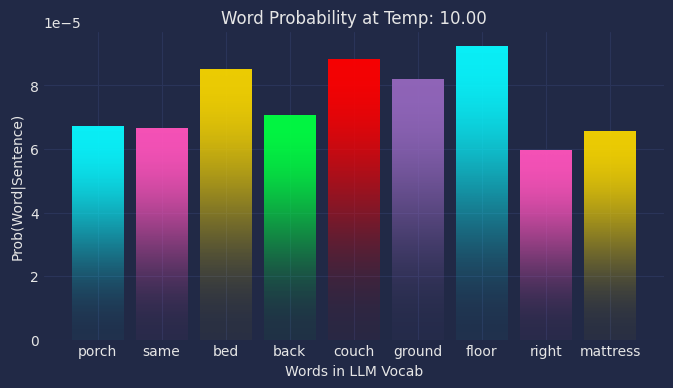

Generated word:  mattress         ( token index: 33388,          logit:-86.25,          prob: 0.0000 )


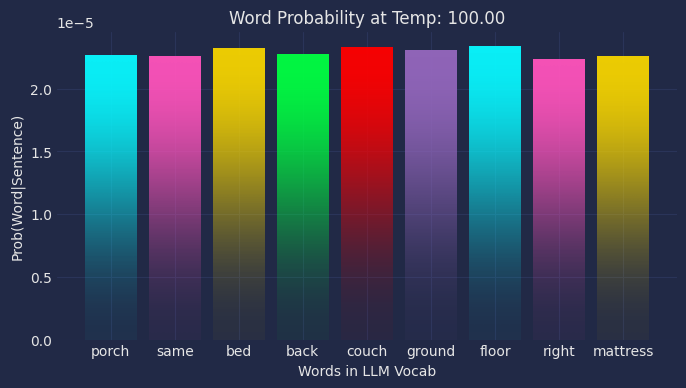

In [230]:
#| label: fig-gapminder
#| fig-cap: "Life Expectancy and GDP"
#| fig-subcap:
#|   - "Gapminder: 1957"

torch.manual_seed(0)
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook"

import seaborn as sns
import matplotlib.pyplot as plt
try: 
  import mplcyberpunk
except:
   %pip install mplcyberpunk
   import mplcyberpunk



def plot_bar_chart(words, probs, temp=None):
    """
    Plots a bar chart of words and their probabilities
    """

    # Extract the values for Plotly
    words = words
    probs = probs 
    colors = [f"C{i}" for i in range(len(words))]


    plot_params = {
      'xlabel': 'Words in LLM Vocab',
      'ylabel': 'Prob(Word|Sentence)',
      'title': f"Word Probability at Temp: {temp:.2f}"}

    # plt.figure(figsize=(4,2))
    plt.style.use('cyberpunk')
    fig, ax = plt.subplots(figsize=(8,4))
    bars = ax.bar(words, probs, color=colors, zorder=2)
    mplcyberpunk.add_bar_gradient(bars=bars)
    ax.set(**plot_params)
    plt.show()



def next_word_prediction(prompt: str, temp=0.5, 
                         output_bar_chart=False,
                         output_probs=False, 
                         words_to_plot=None):
  """
  Extracts next word prediction from the defined LLM
  """
  # Tokenize/encode input prompt
  input_ids = tokenizer.encode(prompt, return_tensors="pt")

  # Pass to GPU
  input_ids = input_ids.to("cuda:1")
  temperature =temp#0.75#10.#0.001
  # Generate the output with adjusted temperature
  outputs = model.generate(input_ids,
                            max_new_tokens=1, #Just want one word generated
                            temperature=temperature, #Set temp
                            output_scores=True, #Output model word scores
                            output_logits=True, #Outout logits
                            return_dict_in_generate=True,
                            do_sample=True, #Perform sampling for next word
                            pad_token_id=tokenizer.eos_token_id)

  # Get the generated token ID, logit, and probability
  generated_token_id = outputs.sequences[0][-1].item()
  generated_token_logit = outputs.logits[0][0][generated_token_id]
  softmax_prob =  F.softmax(outputs.logits[0][0]/torch.tensor([temperature]).to(device)  ,dim=-1)
  generated_token_prob = softmax_prob[generated_token_id].item()
  # Decode the generated token ID to a word
  generated_word = tokenizer.decode([generated_token_id])

  print(f"Generated word: {generated_word} \
        ( token index: {generated_token_id},\
          logit:{generated_token_logit:.2f},\
          prob: {generated_token_prob:.4f} )")

  
  # Get logits for all tokens
  logits = outputs.logits[0][0]/torch.tensor([temperature]).to(device)

  # Apply softmax to get probabilities
  probabilities = F.softmax(logits, dim=-1)
  all_words = [tokenizer.decode([idx]).replace(" ", "") for idx in range(len(probabilities))]

  # Get the top 10 probable words
  top_10_probabilities, top_10_indices = torch.topk(probabilities, 100)

  # Decode the top 10 tokens to words
  top_10_words = [tokenizer.decode([idx]).replace(" ", "") for idx in top_10_indices]

  if output_probs:
    # Print the table of probabilities
    print("Index\t \tWord\t \tProbability")
    print("-"*35)
    for indx, word, prob in zip(top_10_indices, top_10_words, top_10_probabilities):
        print(f"{indx} \t \t{word}\t \t{prob.item():.6f}")


  if output_bar_chart:
     
    if words_to_plot is not None:
        
        words_in_encode = [tokenizer.encode(" "+word, return_tensors="pt") for word in words_to_plot]
      
        words_in_prob = [softmax_prob[idx[0]].cpu().numpy()[0] for idx in words_in_encode]

        plot_bar_chart(words = words_to_plot, probs =  words_in_prob, temp=temp)

    else:
        plot_bar_chart(words = top_10_words, probs =  top_10_probabilities.cpu().numpy())


  #Return the generated word
  return generated_word 



prompt = "The cat slept on the"
temps = [0.001, 0.25, 0.5, 1., 2., 5., 10., 100.]

# for i in temps:#range(10):
#   print(f"Temp: {i}")
#   generated_word  = next_word_prediction(prompt, temp=i)
#   # prompt += generated_word 
#   print(prompt + generated_word )
import random
words_to_plot=["floor", "bed", "ground", "back", "couch", "same", "mattress", "porch", "right"]
random.seed(0)
random.shuffle(words_to_plot)


for ii in temps:
  next_word_prediction(prompt, temp=ii, output_bar_chart=True, words_to_plot=words_to_plot)

# next_word_prediction(prompt, temp=0.25, output_bar_chart=True,  words_to_plot=words_to_plot)

# next_word_prediction(prompt, temp=0.5, output_bar_chart=True,  words_to_plot=words_to_plot)

# next_word_prediction(prompt, temp=1., output_bar_chart=True,  words_to_plot=words_to_plot)

# next_word_prediction(prompt, temp=3., output_bar_chart=True,  words_to_plot=words_to_plot)

# next_word_prediction(prompt, temp=100., output_bar_chart=True,  words_to_plot=words_to_plot)

In [188]:
# import torch
# torch.cuda.empty_cache()
# import os
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [189]:
# import torch

# # Reset max memory allocated
# torch.cuda.reset_max_memory_allocated()

# # Reset max memory cached
# torch.cuda.reset_max_memory_cached()


/usr/local/lib/python3.11/dist-packages/torch/cuda/memory.py:343: FutureWarning: torch.cuda.reset_max_memory_allocated now calls torch.cuda.reset_peak_memory_stats, which resets /all/ peak memory stats.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/cuda/memory.py:369: FutureWarning: torch.cuda.reset_max_memory_cached now calls torch.cuda.reset_peak_memory_stats, which resets /all/ peak memory stats.
  warnings.warn(


In [23]:
# torch.cuda.empty_cache()
# print(torch.cuda.memory_allocated()/1024**2)
# print(torch.cuda.memory_reserved()/1024**2)
# torch.cuda.empty_cache()


7288.380859375
7290.0


In [26]:
# def empty_cache_on_device(device_id):
#     with torch.cuda.device(device_id):
#         torch.cuda.empty_cache()

# empty_cache_on_device(0)         

In [21]:
# import gc

# # Invoke garbage collector
# gc.collect()

740

In [193]:
#This works for clearing the current GPUs memory 
# torch.device("cuda:1")
# torch._C._cuda_clearCublasWorkspaces()
# torch._dynamo.reset()
# import gc
# gc.collect()
# torch.cuda.empty_cache()

In [28]:
#Generate LLM pipeline
#Create the generation pipeline
# LLM_generator = pipeline(
#     model_to_load_task,
#     model = model_to_load,
#     tokenizer = tokenizer,
#     return_full_text = False, 
#     max_new_tokens = 500,
#     do_sample = False, 
# )

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [31]:
# # Prompt
# prompt = "The capital of France is"
# messages = [{"role": "user", 
#             "content": prompt 
#             }]

# output = LLM_generator(messages) 
# print(output[0]["generated_text"])

 The capital of France is Paris.


In [27]:
# # Set up and prompt

# prompt = "The capital of France is"



# # Tokenize input prompt
# input_ids = tokenizer(prompt, return_tensors ="pt").input_ids
# #Pass to GPU
# input_ids = input_ids.to("cuda:1")

# # Get the output of the model before the lm_head
# model_output = model.model(input_ids)

# # Get the output of the lm_head
# lm_head_output = model.lm_head(model_output[0])

# token_id = lm_head_output[0,-1].argmax(-1)
# tokenizer.decode(token_id)

You are not running the flash-attention implementation, expect numerical differences.


'Paris'

In [67]:
# prompt = "The sleepy cat slept on the"#"The capital of France is"

# # Tokenize input prompt
# input_ids = tokenizer.encode(prompt, return_tensors ="pt")
# #Pass to GPU
# input_ids = input_ids.to("cuda:1")


# outputs = model.generate(input_ids, 
#                          max_new_tokens=1, 
#                          output_scores=True, 
#                          return_dict_in_generate=True, 
#                          pad_token_id=tokenizer.eos_token_id)


# # Get the generated token ID
# generated_token_id = outputs.sequences[0][-1].item()

# # Decode the generated token ID to a word
# generated_word = tokenizer.decode([generated_token_id])

# print("Generated word:", generated_word)



Generated word: mat


In [9]:
# import torch.nn.functional as F

# # Assuming you have already imported and set up your tokenizer and model
# prompt = "The cat slept on the"

# # Tokenize input prompt
# input_ids = tokenizer.encode(prompt, return_tensors="pt")

# # Pass to GPU
# input_ids = input_ids.to("cuda:1")

# # Forward pass to get logits for the next token
# with torch.no_grad():
#     outputs = model(input_ids)
#     logits = outputs.logits

# # Adjust temperature
# temperature = 100.0 # You can change this value to adjust the temperature
# scaled_logits = logits[0, -1, :] / temperature


# # Get the logits for the last token in the input sequence
# last_token_logits = scaled_logits# logits[0, -1, :]

# # Apply softmax to get probabilities
# probabilities = F.softmax(last_token_logits, dim=-1)

# # Get the top 10 probable words
# top_10_probabilities, top_10_indices = torch.topk(probabilities, 10)

# # Decode the top 10 tokens to words
# top_10_words = [tokenizer.decode([idx]) for idx in top_10_indices]

# print(f"The selected word: \n {prompt} {top_10_words[0]}")
# print("Top 10 probable next words:", top_10_words)

# # Print the table
# print("Word\tProbability")
# print("-"*20)
# for word, prob in zip(top_10_words, top_10_probabilities):
#     print(f"{word}\t{prob.item():.6f}")


# selected_idx = np.random.choice(top_10_indices.cpu(), p=top_10_probabilities.cpu().numpy()/sum(top_10_probabilities.cpu().numpy()))
# selected_word = tokenizer.decode([selected_idx.item()])

# print("Selected word:", selected_word)    


The selected word: 
 The cat slept on the  floor
Top 10 probable next words: [' floor', ' couch', ' bed', ' ground', ' sofa', ' side', ' other', ' roof', ' back', ' grass']
Word	Probability
--------------------
 floor	0.000023
 couch	0.000023
 bed	0.000023
 ground	0.000023
 sofa	0.000023
 side	0.000023
 other	0.000023
 roof	0.000023
 back	0.000023
 grass	0.000023
Selected word:  bed


In [97]:
# # Get the generated token ID
# generated_token_id = outputs.sequences[0][-1].item()

# # Decode the generated token ID to a word
# generated_word = tokenizer.decode([generated_token_id])

# print("Generated word:", generated_word)

AttributeError: 'CausalLMOutputWithPast' object has no attribute 'sequences'

In [13]:
# # Assuming you have already imported and set up your tokenizer and model
# prompt = "The cat slept on the"

# # Tokenize input prompt
# input_ids = tokenizer.encode(prompt, return_tensors="pt")

# # Pass to GPU
# input_ids = input_ids.to("cuda:1")

# # Generate the output with adjusted temperature
# outputs = model.generate(input_ids,
#                           max_new_tokens=1,
#                           temperature= 2.0,  # You can change this value to adjust the temperature
#                           output_scores=True,
#                           return_dict_in_generate=True,
#                           do_sample=True,
#                           pad_token_id=tokenizer.eos_token_id)

# # Get the generated token ID
# generated_token_id = outputs.sequences[0][-1].item()

# # Decode the generated token ID to a word
# generated_word = tokenizer.decode([generated_token_id])

# print("Generated word:", generated_word)


Generated word:  grass


In [210]:
# probabilities.argmax().item()
# top_10_indices
# outputs.logits[0][0]/100
# top_10_indices
# [tokenizer.decode([idx]).replace(" ", "") for idx in top_10_indices]
# probabilities.sum()
# outputs.past_key_values
# model.config
# words_to_plot =["floor", "bed"]
# for word in words_to_plot:
#     print(tokenizer.encode(word, return_tensors="pt"))

GPT2Config {
  "_name_or_path": "openai-community/gpt2",
  "activation_function": "gelu_new",
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "transformers_version": "4.44.2",
  "use_cache": true,
  "vocab_size": 50257
}

In [70]:
# outputs.logits[0].size()
# print(F.softmax(outputs.logits[0][0]).argmax())
# print(outputs.sequences[0][-1])
# tokenizer.decode(outputs.sequences[0][-1])

tensor(4314, device='cuda:1')
tensor(4314, device='cuda:1')


/tmp/ipykernel_346/3335326152.py:2: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  print(F.softmax(outputs.logits[0][0]).argmax())


' floor'

In [81]:
# F.softmax(outputs.logits[0][0])[43].item()

/tmp/ipykernel_346/2671969968.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  F.softmax(outputs.logits[0][0])[43].item()


6.473852920407808e-08